In [1]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [2]:
path = "/content/gdrive/MyDrive/Praktikum/Praktikum05/Data"

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [5]:
# Memuat dataset
file_path = 'Iris.csv'
df = pd.read_csv(path + '/Iris.csv')

# Menampilkan 5 data pertama
print("Data Head:")
print(df.head())

# Memisahkan fitur (X) dan target (y)
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
target = 'Species'

X = df[features]
y = df[target]

# Menampilkan informasi data
print("\nInformasi Fitur (X):")
print(X.head())
print("\nInformasi Target (y):")
print(y.head())

Data Head:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Informasi Fitur (X):
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Informasi Target (y):
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


In [6]:
# Membagi data menjadi 80% training dan 20% testing
# random_state=42 digunakan agar hasil pembagian datanya konsisten (reproducible)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nJumlah data latih: {X_train.shape[0]} sampel")
print(f"Jumlah data uji: {X_test.shape[0]} sampel")


Jumlah data latih: 120 sampel
Jumlah data uji: 30 sampel


In [7]:
# Inisialisasi model Decision Tree
# Menggunakan random_state=42 agar hasil pohon keputusannya konsisten
model_dt = DecisionTreeClassifier(random_state=42)

# Melatih model dengan data training
model_dt.fit(X_train, y_train)

print("\nModel Decision Tree berhasil dilatih.")


Model Decision Tree berhasil dilatih.


In [8]:
# Membuat prediksi pada data uji
y_pred = model_dt.predict(X_test)

# 1. Menghitung Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model: {accuracy * 100:.2f}%")

# 2. Menampilkan Confusion Matrix
print("\nConfusion Matrix:")
# Mendapatkan nama kelas secara dinamis dari model
class_names = model_dt.classes_
cm = confusion_matrix(y_test, y_pred, labels=class_names)
# Tampilkan dengan label agar mudah dibaca
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print(cm_df)

# 3. Menampilkan Classification Report
print("\nClassification Report:")
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)


Akurasi Model: 100.00%

Confusion Matrix:
                 Iris-setosa  Iris-versicolor  Iris-virginica
Iris-setosa               10                0               0
Iris-versicolor            0                9               0
Iris-virginica             0                0              11

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30




Menampilkan visualisasi Decision Tree...


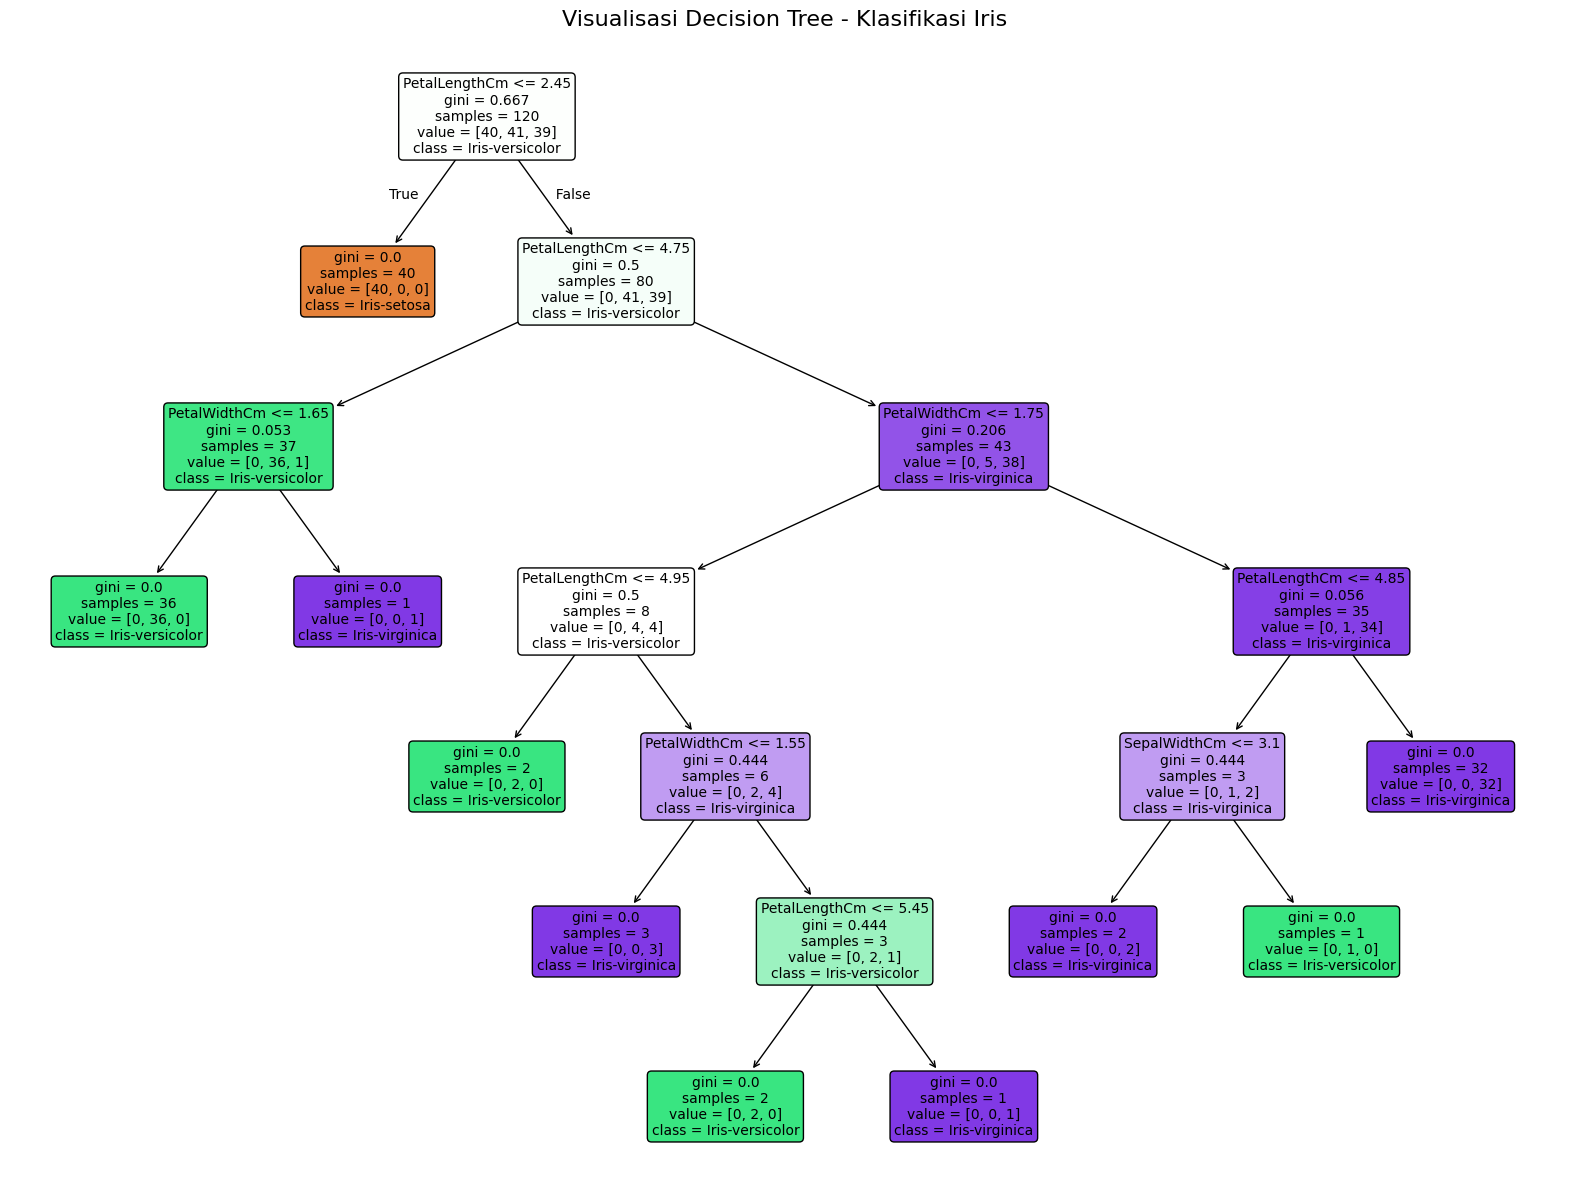

In [9]:
print("\nMenampilkan visualisasi Decision Tree...")

plt.figure(figsize=(20, 15))  # Atur ukuran gambar agar lebih besar dan jelas
plot_tree(model_dt,
          feature_names=features,
          class_names=class_names,
          filled=True,     # Beri warna pada node
          rounded=True,    # Buat sudut node membulat
          fontsize=10)     # Atur ukuran font

plt.title("Visualisasi Decision Tree - Klasifikasi Iris", fontsize=16)
plt.show()